In [15]:
import torch
from torch import nn
from torch.nn import functional as F
import sys
import os
import math
import random
import collections
import re

# 将上级目录添加到 sys.path，以便导入 d2l_utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import d2l_utils

# ==========================================
# 1. 数据预处理：强制使用“单词”级别
# ==========================================
# 为了做完形填空，我们需要模型理解“单词”而不是“字母”
# 因此我们需要重写一部分数据加载逻辑

def load_corpus_time_machine_word(max_tokens=-1):
    """返回时光机器数据集的词元索引列表和词表（单词级别）"""
    lines = d2l_utils._read_time_machine()
    # 这里改为 'word'，按单词切分
    tokens = d2l_utils.tokenize(lines, 'word')
    vocab = d2l_utils.Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

class SeqDataLoaderWord:
    """加载序列数据的迭代器（单词级别）"""
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = d2l_utils.seq_data_iter_random
        else:
            self.data_iter_fn = d2l_utils.seq_data_iter_sequential
        # 调用我们自定义的单词级加载函数
        self.corpus, self.vocab = load_corpus_time_machine_word(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

def load_data_time_machine_word(batch_size, num_steps,
                           use_random_iter=False, max_tokens=10000):
    """返回时光机器数据集的迭代器和词表（单词级别）"""
    data_iter = SeqDataLoaderWord(
        batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab

# 定义 try_gpu 函数
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

# 加载数据 (使用单词级别!)
batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine_word(batch_size, num_steps)
print(f"词表大小 (单词数): {len(vocab)}")


词表大小 (单词数): 4580


In [16]:
# ==========================================
# 2. 定义双向 RNN 模型
# ==========================================
class BiRNNModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens, num_layers, **kwargs):
        super(BiRNNModel, self).__init__(**kwargs)
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.rnn = nn.GRU(vocab_size, num_hiddens, num_layers, bidirectional=True)
        self.linear = nn.Linear(num_hiddens * 2, vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        return torch.zeros((2 * self.rnn.num_layers, batch_size, self.num_hiddens), device=device)


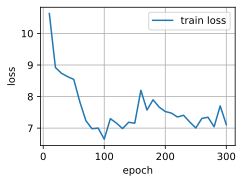

In [17]:
# ==========================================
# 3. 训练逻辑
# ==========================================
def mask_input(X, vocab):
    masked_X = X.clone()
    batch_size, num_steps = X.shape
    target_indices = torch.randint(0, num_steps, (batch_size,))
    target_labels = []
    for i in range(batch_size):
        idx = target_indices[i]
        target_labels.append(X[i, idx].item())
        masked_X[i, idx] = 0 # 假设 0 是 <unk>
    return masked_X, target_indices, torch.tensor(target_labels)

def train_bi_rnn(net, train_iter, vocab, lr, num_epochs, device):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    net = net.to(device)
    animator = d2l_utils.Animator(xlabel='epoch', ylabel='loss', legend=['train loss'])

    for epoch in range(num_epochs):
        metric = d2l_utils.Accumulator(2)
        for X, _ in train_iter:
            batch_size = X.shape[0]
            state = net.begin_state(device, batch_size)
            masked_X, target_indices, target_labels = mask_input(X, vocab)

            masked_X = masked_X.to(device)
            target_labels = target_labels.to(device)
            target_indices = target_indices.to(device)

            y_hat, state = net(masked_X, state)

            flat_indices = target_indices * batch_size + torch.arange(batch_size, device=device)
            masked_y_hat = y_hat[flat_indices]

            l = loss_fn(masked_y_hat, target_labels)

            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            metric.add(l.item() * batch_size, batch_size)

        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, [metric[0] / metric[1]])
            print(f'Epoch {epoch + 1}, Loss: {metric[0] / metric[1]:.4f}')

# 开始训练
vocab_size = len(vocab)
num_hiddens = 256
num_layers = 2
device = try_gpu()

net = BiRNNModel(vocab_size, num_hiddens, num_layers)
# 训练 300 轮
train_bi_rnn(net, train_iter, vocab, lr=0.01, num_epochs=300, device=device)


In [18]:
# ==========================================
# 4. 考试解题功能
# ==========================================

def solve_exam(net, text, questions, vocab, device, num_steps=35):
    """
    自动做完形填空题
    :param net: 训练好的模型
    :param text: 文章内容，挖空处用 '_' 表示
    :param questions: 题目列表，每个元素是一个字典 {'A': 'word', 'B': 'word', ...}
    :param vocab: 词表
    :param device: 设备
    :param num_steps: 模型处理的序列长度
    """
    net.eval()
    # 1. 预处理文章：将文本转为单词列表
    # 简单的分词，去掉标点符号（除了下划线）
    clean_text = text.lower()
    clean_text = re.sub(r'[^a-z0-9_]+', ' ', clean_text)
    words = clean_text.split()

    # 2. 找到所有下划线的位置
    blank_indices = [i for i, x in enumerate(words) if '_' in x]

    if len(blank_indices) != len(questions):
        print(f"警告: 文章中的空缺数 ({len(blank_indices)}) 与题目数 ({len(questions)}) 不一致！")

    print("-" * 50)
    print("开始做题...")

    results = []

    for q_idx, blank_pos in enumerate(blank_indices):
        if q_idx >= len(questions): break

        options = questions[q_idx] # {'A': '...', 'B': '...'}

        # 3. 截取上下文窗口
        # 我们需要以 blank_pos 为中心，截取长度为 num_steps 的片段
        # 尽量让 blank 位于中间
        half_window = num_steps // 2
        start = max(0, blank_pos - half_window)
        end = min(len(words), start + num_steps)

        # 如果右边不够，往左边借
        if end - start < num_steps and start > 0:
            start = max(0, end - num_steps)

        window_words = words[start:end]

        # 找到 blank 在窗口中的相对位置
        # 注意：window_words 中可能有多个 '_'，我们需要找到对应当前题目的那个
        # 简单起见，我们假设窗口里离中心最近的 '_' 是当前题目
        # 或者直接计算偏移量
        relative_blank_pos = blank_pos - start

        # 4. 转换为索引
        input_indices = []
        for w in window_words:
            if '_' in w:
                input_indices.append(0) # <unk> 作为 mask
            elif w in vocab.token_to_idx:
                input_indices.append(vocab[w])
            else:
                input_indices.append(vocab['<unk>'])

        # 填充 padding (如果窗口不够长)
        if len(input_indices) < num_steps:
            input_indices = input_indices + [0] * (num_steps - len(input_indices))

        X = torch.tensor(input_indices, device=device).reshape(1, -1)
        state = net.begin_state(device, batch_size=1)

        # 5. 模型预测
        with torch.no_grad():
            y_hat, _ = net(X, state)
            # y_hat: (num_steps, vocab_size)

            # 获取 blank 位置的预测向量
            pred_logits = y_hat[relative_blank_pos]

            # 6. 比较选项概率
            best_option = None
            best_score = -float('inf')

            print(f"\n第 {q_idx + 1} 题 (上下文: ...{' '.join(window_words)}...)")

            for opt_key, opt_word in options.items():
                opt_word = opt_word.lower()
                if opt_word in vocab.token_to_idx:
                    word_idx = vocab[opt_word]
                    score = pred_logits[word_idx].item()
                    print(f"  选项 {opt_key}: {opt_word} (得分: {score:.4f})")
                else:
                    score = -1000.0 # 单词不在词表中，给个极低分
                    print(f"  选项 {opt_key}: {opt_word} [未知词 - 跳过]")

                if score > best_score:
                    best_score = score
                    best_option = opt_key

            print(f"  => 推荐答案: {best_option}")
            results.append(best_option)

    print("-" * 50)
    return results


In [19]:
# ==========================================
# 5. 测试用例
# ==========================================

# 构造一篇包含 Time Machine 词汇的“假”文章
# 注意：因为我们的模型只在 Time Machine 上训练过，所以只能做包含这些词的题
exam_text = """
The time traveller proceeded to explain his theory.
He said that there are really four dimensions, three which we call the three planes of space,
and a fourth, _ . There is no difference between time and any of the three dimensions of space except that our consciousness moves along it.
But some foolish people think that _ is only a kind of space.
"""

exam_questions = [
    {'A': 'time', 'B': 'apple', 'C': 'car', 'D': 'book'},  # 第1空：time
    {'A': 'space', 'B': 'time', 'C': 'water', 'D': 'fire'} # 第2空：time (原文逻辑)
]

# 运行考试
answers = solve_exam(net, exam_text, exam_questions, vocab, device)
print("最终答案列表:", answers)


--------------------------------------------------
开始做题...

第 1 题 (上下文: ...there are really four dimensions three which we call the three planes of space and a fourth _ there is no difference between time and any of the three dimensions of space except that our...)
  选项 A: time (得分: -7.4025)
  选项 B: apple (得分: -20.5972)
  选项 C: car [未知词 - 跳过]
  选项 D: book [未知词 - 跳过]
  => 推荐答案: A

第 2 题 (上下文: ..._ there is no difference between time and any of the three dimensions of space except that our consciousness moves along it but some foolish people think that _ is only a kind of space...)
  选项 A: space (得分: -8.1507)
  选项 B: time (得分: -7.4000)
  选项 C: water (得分: -20.6903)
  选项 D: fire (得分: -11.3703)
  => 推荐答案: B
--------------------------------------------------
最终答案列表: ['A', 'B']
